# Phase 4: Forecasting Models - XGBoost vs. LSTM

XGBoost gets the hand-engineered feature table (lags, rolling
stats, calendar, temperature) while the LSTM gets something deliberately
different: a raw sliding window of the past 168 hours of demand and
temperature, without pre-computed lag/rolling features, and the model has to
discover daily/weekly structure on its own.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)

## 1. Load data and define the feature list

The saved CSVs contain every column from the pipeline, not just the final
chosen features. This includes raw `market_demand` (nearly a clone of the
target, since Market Demand = Ontario Demand + exports), raw `hoep`
(same-hour price, not available at forecast time), and raw `temperature_c` 
(the real, non-noisy value, we only want the forecast-simulated version).

In [2]:
train_df = pd.read_csv('../data/processed/train.csv', parse_dates=['datetime'])
test_2023 = pd.read_csv('../data/processed/test_2023.csv', parse_dates=['datetime'])
test_2024 = pd.read_csv('../data/processed/test_2024.csv', parse_dates=['datetime'])
test_2025 = pd.read_csv('../data/processed/test_2025.csv', parse_dates=['datetime'])

TARGET_COL = 'ontario_demand'
EXCLUDE_COLS = {
    'datetime', TARGET_COL,
    'market_demand',       # near-duplicate of the target - leakage
    'hoep',                # raw same-hour price - not available at forecast time
    'temperature_c'        # raw actual temperature - only the temperature_c_forecast version is fair game
}

feature_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]
print(f"Feature count: {len(feature_cols)}")
print(feature_cols)

Feature count: 28
['demand_lag_24h', 'hoep_lag_24h', 'demand_lag_48h', 'hoep_lag_48h', 'demand_lag_72h', 'hoep_lag_72h', 'demand_lag_168h', 'hoep_lag_168h', 'demand_lag_336h', 'hoep_lag_336h', 'demand_rolling_24h_mean', 'demand_rolling_24h_std', 'demand_rolling_48h_mean', 'demand_rolling_72h_mean', 'demand_rolling_168h_mean', 'demand_rolling_168h_std', 'demand_rolling_336h_mean', 'demand_rolling_336h_std', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'is_pandemic_period', 'temperature_c_forecast', 'heating_degree_hours', 'cooling_degree_hours']


## 2. XGBoost

Carving out a validation slice (2022) from training, used only for early
stopping so the model stops adding trees once it no longer improves on data
it wasn't fit to. This is separate from the 2023-2025 test sets, which stay
untouched until final evaluation below.

In [3]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_distributions = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
}

# 5 sequential, chronological train/val folds built for time-series data (prevents
# data leakage, never trains on data from future to predict past)
tscv = TimeSeriesSplit(n_splits=5)

# Iterate through random combinations of the parameter values and evaluate 
search = RandomizedSearchCV(
    XGBRegressor(n_estimators=500, random_state=42),    # initialize model with 500 decision trees
    param_distributions=param_distributions,
    n_iter=30,                                          # 30 random combinations, not exhaustive grid
    cv=tscv,                                            # use the TimeSeriesSplit
    scoring='neg_mean_absolute_error',                  # MAE for scoring metric, negative so maximum is lowest error
    random_state=42,
)
search.fit(train_df[feature_cols], train_df[TARGET_COL])

# Print parameters that produced the best performance
print(search.best_params_)

{'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 1, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


In [4]:
xgb_fit_df = train_df[train_df['datetime'] < '2022-01-01']
xgb_val_df = train_df[train_df['datetime'] >= '2022-01-01']

# Build model using best parameters from search
xgb_model = XGBRegressor(
    **search.best_params_,
    n_estimators=1000,              # use 1000 decision trees
    early_stopping_rounds=30,       # stop training if validation score doesn't improve for 30 consecutive trees
    random_state=42,
)

xgb_model.fit(
    xgb_fit_df[feature_cols], xgb_fit_df[TARGET_COL],
    eval_set=[(xgb_val_df[feature_cols], xgb_val_df[TARGET_COL])],
    verbose=False,
)

print(f"Best iteration: {xgb_model.best_iteration} (of 1000 max)")

Best iteration: 152 (of 1000 max)


## 3. Evaluation function (shared by both models)

In [5]:
def evaluate(y_true, y_pred, model_name, year_label):
    mae = mean_absolute_error(y_true, y_pred)                   # average absolute distance from actual value
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))          # square root of average squared distance from actual value (punishes outliers more than MAE)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100    # expresses average error as percentage of actual value (scale-indifferent when comparing performance)
    print(f"{model_name:>10} {year_label:>15}:  MAE = {mae:8.1f} MW   RMSE = {rmse:8.1f} MW   MAPE = {mape:5.2f}%")
    return {'model': model_name, 'year': year_label, 'mae': mae, 'rmse': rmse, 'mape': mape}

results = []
for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    preds = xgb_model.predict(test_set[feature_cols])
    results.append(evaluate(test_set[TARGET_COL].values, preds, 'XGBoost', year_label))

   XGBoost            2023:  MAE =    488.8 MW   RMSE =    636.4 MW   MAPE =  3.09%
   XGBoost            2024:  MAE =    535.9 MW   RMSE =    710.5 MW   MAPE =  3.30%
   XGBoost  2025 (partial):  MAE =    511.0 MW   RMSE =    653.1 MW   MAPE =  3.05%


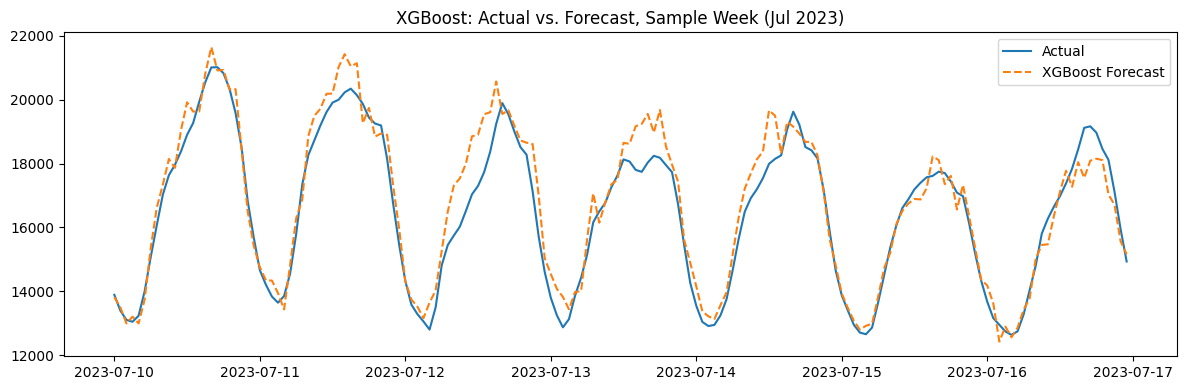

In [8]:
# Visual check: one sample week from 2023, forecast vs actual
sample_week = test_2023[(test_2023['datetime'] >= '2023-07-10') & (test_2023['datetime'] < '2023-07-17')]
sample_preds = xgb_model.predict(sample_week[feature_cols])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample_week['datetime'], sample_week[TARGET_COL], label='Actual')
ax.plot(sample_week['datetime'], sample_preds, label='XGBoost Forecast', linestyle='--')
plt.title('XGBoost: Actual vs. Forecast, Sample Week (Jul 2023)')
plt.legend()
plt.tight_layout()
plt.show()

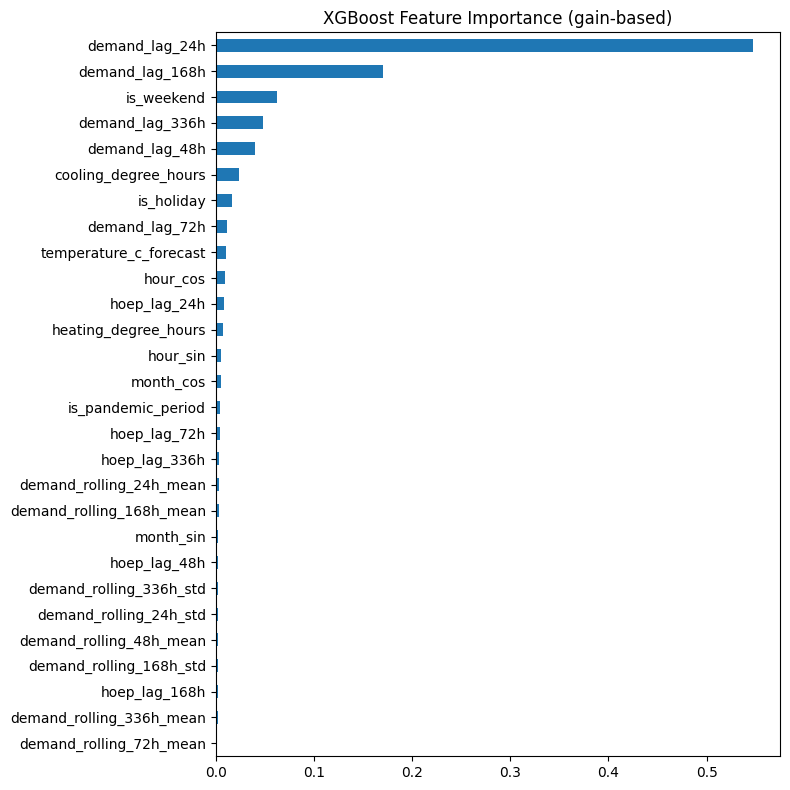

In [6]:
# Feature importance from the final trained model
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
plt.title('XGBoost Feature Importance (gain-based)')
plt.tight_layout()
plt.show()

## 4. The LSTM -- raw sequences, not engineered features

Building sliding windows of the past 168 raw hours of demand and
temperature (forecast-simulated) and predicting demand 24 hours ahead,
same conditions as feature engineering.

In [7]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# For M1 Mac users: confirm the M1 GPU is actually being used via Metal, not silently
# falling back to CPU-only. Should list a 'GPU' device alongside 'CPU'.
print(f"TensorFlow version: {tf.__version__}")
print(f"Devices available: {tf.config.list_physical_devices()}")

TensorFlow version: 2.18.1
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
full_df = pd.read_csv('../data/processed/model_ready_dataset.csv', parse_dates=['datetime'])
full_df = full_df.sort_values('datetime').reset_index(drop=True)

SEQ_COLS = ['ontario_demand', 'temperature_c_forecast']
WINDOW = 168   # trailing hours of raw history
HORIZON = 24   # predict this many hours ahead of the END of the window


def build_sequences(frame: pd.DataFrame, target_start: pd.Timestamp, target_end: pd.Timestamp):
    """
    Builds (X, y, datetimes) for every target timestamp in
    [target_start, target_end), using the WINDOW raw hours ending
    HORIZON hours before each target -- i.e. exactly the data that would
    genuinely be available at forecast time. Sequence inputs are allowed
    to reach into data before target_start (real past history); only the
    TARGET must fall inside the requested range.
    """
    # Put values and timestamps in numpy arrays for higher performance indexing 
    values = frame[SEQ_COLS].values  
    timestamps = frame['datetime'].values

    # Identify row indices where datetime is after start and before end
    X, y, dt_out = [], [], []
    target_mask = (frame['datetime'] >= target_start) & (frame['datetime'] < target_end)
    target_indices = np.where(target_mask)[0]

    for idx in target_indices:
        window_end = idx - HORIZON        # last index INCLUDED in the input window
        window_start = window_end - WINDOW + 1
        if window_start < 0:
            continue  # not enough history yet (only affects the very start of 2002)
        X.append(values[window_start:window_end + 1])
        y.append(values[idx, 0])          # ontario_demand at the target index
        dt_out.append(timestamps[idx])

    return np.array(X), np.array(y), np.array(dt_out)


X_fit, y_fit, _ = build_sequences(full_df, pd.Timestamp('2002-01-01'), pd.Timestamp('2022-01-01'))
X_val, y_val, _ = build_sequences(full_df, pd.Timestamp('2022-01-01'), pd.Timestamp('2023-01-01'))
X_test_2023, y_test_2023, dt_2023 = build_sequences(full_df, pd.Timestamp('2023-01-01'), pd.Timestamp('2024-01-01'))
X_test_2024, y_test_2024, dt_2024 = build_sequences(full_df, pd.Timestamp('2024-01-01'), pd.Timestamp('2025-01-01'))
X_test_2025, y_test_2025, dt_2025 = build_sequences(full_df, pd.Timestamp('2025-01-01'), pd.Timestamp('2025-05-01'))

print(f"Fit sequences:  {X_fit.shape}")
print(f"Val sequences:  {X_val.shape}")
print(f"Test 2023:      {X_test_2023.shape}")

Fit sequences:  (171890, 168, 2)
Val sequences:  (8760, 168, 2)
Test 2023:      (8760, 168, 2)


### Scaling

A separate scaler from XGBoost's, since this is scaling raw sequence
values (demand in MW, temperature in °C), not the engineered feature
table. Fit on the flattened FIT sequences only (non-validation training data), then applied everywhere
else.

In [9]:
n_features = len(SEQ_COLS)
seq_scaler = StandardScaler()
seq_scaler.fit(X_fit.reshape(-1, n_features))

def scale_sequences(X):
    shape = X.shape
    return seq_scaler.transform(X.reshape(-1, n_features)).reshape(shape)

X_fit_s = scale_sequences(X_fit)
X_val_s = scale_sequences(X_val)
X_test_2023_s = scale_sequences(X_test_2023)
X_test_2024_s = scale_sequences(X_test_2024)
X_test_2025_s = scale_sequences(X_test_2025)

# Scale the output as well to prevent MSE loss from creating huge loss that spirals
target_scaler = StandardScaler()
target_scaler.fit(y_fit.reshape(-1, 1))

y_fit_s = target_scaler.transform(y_fit.reshape(-1, 1)).flatten()
y_val_s = target_scaler.transform(y_val.reshape(-1, 1)).flatten()

### Building and training the LSTM

A simple architecture on purpose: one LSTM layer summarizing the 168-hour
window, a small Dense layer, then a single output neuron predicting
demand. `EarlyStopping` plays the same role early stopping did for
XGBoost -- stop once validation loss stops improving, using the same 2022
validation period, never touching the real test years.

In [10]:
lstm_model = keras.Sequential([
    layers.Input(shape=(WINDOW, n_features)),       # input shape is 2D matrix with `WINDOW` hours of `n_features` features
    layers.LSTM(64),                                # 64 hidden units for memory
    layers.Dense(32, activation='relu'),            # standard fully connected layer with 32 neurons, using ReLU activation function
    layers.Dense(1),                                # final output layer with 1 neuron to predict demand
])

# Add gradient clipping to cap single weight updates (and prevent exploding gradients from destabliizing training) - historical events like cold snaps, 
# heatwaves, or the pandemic affecting the data of a batch could trigger a large enough gradient update
lstm_model.compile(optimizer=keras.optimizers.Adam(clipnorm=1.0), loss='mse')

# Tells model to stop training if validation performance does not improve after 5 consecutive epochs (full runs through the training data)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_fit_s, y_fit,
    validation_data=(X_val_s, y_val),
    epochs=50,
    batch_size=256,                     # update weights after every 256 samples
    callbacks=[early_stop],
    verbose=1,                          # print progress bars and training/val loss stats during training
)

2026-09-18 09:36:10.352894: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-09-18 09:36:10.352952: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-18 09:36:10.352960: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1789738570.353012 4077000 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1789738570.353087 4077000 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2026-09-18 09:36:11.197701: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


672/672 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - loss: 266513648.0000 - val_loss: 235253936.0000
Epoch 2/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - loss: 231793952.0000 - val_loss: 187485024.0000
Epoch 3/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - loss: 171495632.0000 - val_loss: 122070664.0000
Epoch 4/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - loss: 100521192.0000 - val_loss: 56048440.0000
Epoch 5/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - loss: 38310280.0000 - val_loss: 11325388.0000
Epoch 6/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - loss: 8197241.0000 - val_loss: 2702716.7500
Epoch 7/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - loss: 2511899.0000 - val_loss: 1543424.1250
Epoch 8/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - loss: 1746552.0000 - val_loss: 1172131.6250
Epoch 9/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - loss: 1413688.3750 - val_loss: 1125926.8750
Epoch 10/50
672/672 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - loss: 1344735.7500 - val_loss: 108646

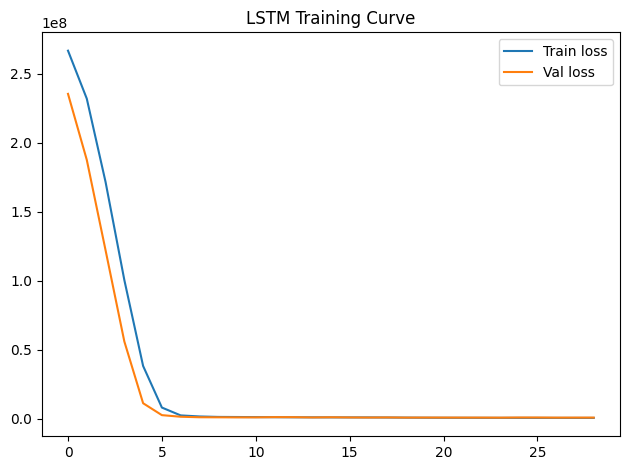

In [11]:
fig, ax = plt.subplots()
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Val loss')
plt.title('LSTM Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluate the LSTM, using the exact same metric function as XGBoost

In [12]:
for year_label, X_s, y_true in [
    ('2023', X_test_2023_s, y_test_2023),
    ('2024', X_test_2024_s, y_test_2024),
    ('2025 (partial)', X_test_2025_s, y_test_2025),
]:
    preds = lstm_model.predict(X_s, verbose=0).flatten()
    results.append(evaluate(y_true, preds, 'LSTM', year_label))

      LSTM            2023:  MAE =    617.1 MW   RMSE =    827.9 MW   MAPE =  3.94%
      LSTM            2024:  MAE =    658.8 MW   RMSE =    911.7 MW   MAPE =  4.12%
      LSTM  2025 (partial):  MAE =    649.8 MW   RMSE =    840.0 MW   MAPE =  3.96%


## 6. Head-to-head comparison

model               LSTM   XGBoost
year                              
2023            3.941479  3.090147
2024            4.118524  3.299907
2025 (partial)  3.964091  3.054169


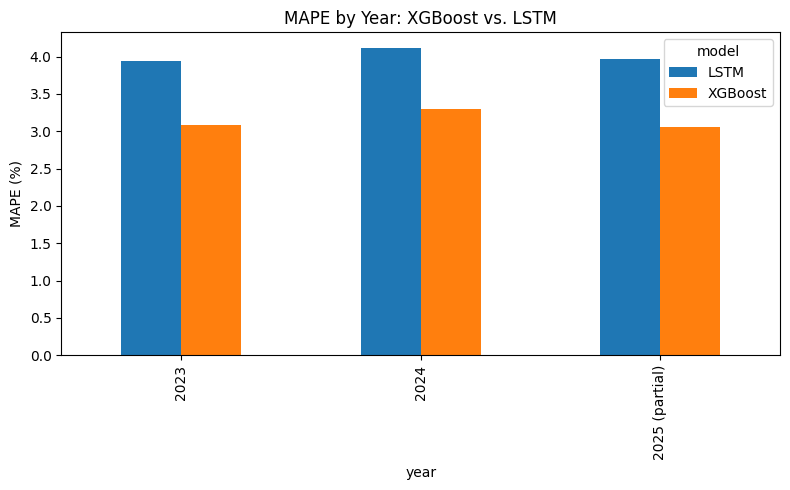

In [13]:
results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='year', columns='model', values='mape')
print(pivot)

pivot.plot(kind='bar', figsize=(8, 5))
plt.title('MAPE by Year: XGBoost vs. LSTM')
plt.ylabel('MAPE (%)')
plt.tight_layout()
plt.show()

## 7. Price Forecasting

The battery optimization aspect of the project needs a PRICE forecast, not a demand
forecast since the battery makes or loses money on price directly. Demand and
price are correlated (demand is one of the two real forces setting
marginal price, alongside supply-side conditions like fuel costs and
available generation) but they're not interchangeable.

We can reuse everything already built above (same dataframes, same leakage
discipline, same train/val/test split) with two changes: the target
becomes `hoep`, and `xgb_model`'s own demand forecast gets added as a new
feature, deliberately injecting the demand-drives-price relationship
directly into this model.

In [14]:
demand_model = xgb_model  # reusing the model trained above, no need to reload anything
demand_feature_cols = feature_cols  # the feature list used for the demand model

for frame in [train_df, test_2023, test_2024, test_2025]:
    frame['demand_forecast'] = demand_model.predict(frame[demand_feature_cols])

train_df[['datetime', 'ontario_demand', 'demand_forecast']].tail()

,datetime,ontario_demand,demand_forecast
180836,2022-12-31 19:00:00,15834,16803.857422
180837,2022-12-31 20:00:00,15465,16394.376953
180838,2022-12-31 21:00:00,15086,15747.195312
180839,2022-12-31 22:00:00,14453,15217.523438
180840,2022-12-31 23:00:00,13965,14303.402344


### Feature list for the Price model

In [15]:
# The original EXCLUDE_COLS already excludes both 'ontario_demand' and 'hoep' -- the demand model
# needed 'hoep' excluded (leaky same-hour price), and the price model needs 'ontario_demand' excluded
# (leaky same-hour demand). No changes needed.
PRICE_TARGET_COL = 'hoep'
price_feature_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]

assert 'ontario_demand' not in price_feature_cols, "leakage: true demand must not be a price feature"
assert PRICE_TARGET_COL not in price_feature_cols
print(f"Feature count: {len(price_feature_cols)}")
print(price_feature_cols)

Feature count: 29
['demand_lag_24h', 'hoep_lag_24h', 'demand_lag_48h', 'hoep_lag_48h', 'demand_lag_72h', 'hoep_lag_72h', 'demand_lag_168h', 'hoep_lag_168h', 'demand_lag_336h', 'hoep_lag_336h', 'demand_rolling_24h_mean', 'demand_rolling_24h_std', 'demand_rolling_48h_mean', 'demand_rolling_72h_mean', 'demand_rolling_168h_mean', 'demand_rolling_168h_std', 'demand_rolling_336h_mean', 'demand_rolling_336h_std', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'is_pandemic_period', 'temperature_c_forecast', 'heating_degree_hours', 'cooling_degree_hours', 'demand_forecast']


### Tuning and final fit -- same pattern as the demand model

In [16]:
price_search = RandomizedSearchCV(
    XGBRegressor(n_estimators=500, random_state=42),
    param_distributions=param_distributions,  # reusing the same grid defined above
    n_iter=30,
    cv=tscv,                                  # reusing the same time series split
    scoring='neg_mean_absolute_error',
    random_state=42,
)
price_search.fit(train_df[price_feature_cols], train_df[PRICE_TARGET_COL])
print(price_search.best_params_)

{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


In [17]:
price_fit_df = train_df[train_df['datetime'] < '2022-01-01']
price_val_df = train_df[train_df['datetime'] >= '2022-01-01']

price_model = XGBRegressor(
    **price_search.best_params_,
    n_estimators=1000,
    early_stopping_rounds=30,
    random_state=42,
)
price_model.fit(
    price_fit_df[price_feature_cols], price_fit_df[PRICE_TARGET_COL],
    eval_set=[(price_val_df[price_feature_cols], price_val_df[PRICE_TARGET_COL])],
    verbose=False,
)
print(f"Best iteration: {price_model.best_iteration}")

Best iteration: 419


### Evaluation

Recall the Surplus Baseload Generation (SBG) findings frombefore: HOEP legitimately
sits at exactly $0 for a meaningful share of hours. MAPE divides by the
true value meaning dividing by zero silently produces `inf` if not handled.
The fix for this is to compute MAPE only over non-zero-price rows, reporting what
fraction got excluded; MAE/RMSE don't have this problem and still cover every row.

In [18]:
def evaluate_price(y_true, y_pred, model_name, year_label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    nonzero_mask = y_true != 0
    pct_excluded = 100 * (1 - nonzero_mask.mean())
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

    print(f"{model_name:>10} {year_label:>15}:  MAE = ${mae:6.2f}/MWh   RMSE = ${rmse:6.2f}/MWh   "
          f"MAPE = {mape:6.1f}% (excluding {pct_excluded:.1f}% zero-price hours)")
    return {'model': model_name, 'year': year_label, 'mae': mae, 'rmse': rmse, 'mape': mape}

price_results = []
for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    preds = price_model.predict(test_set[price_feature_cols])
    price_results.append(evaluate_price(test_set[PRICE_TARGET_COL].values, preds, 'XGBoost', year_label))

   XGBoost            2023:  MAE = $  8.39/MWh   RMSE = $ 18.01/MWh   MAPE =   66.3% (excluding 2.2% zero-price hours)
   XGBoost            2024:  MAE = $  9.88/MWh   RMSE = $ 25.48/MWh   MAPE =   44.1% (excluding 0.9% zero-price hours)
   XGBoost  2025 (partial):  MAE = $ 20.61/MWh   RMSE = $ 55.86/MWh   MAPE =   90.5% (excluding 1.4% zero-price hours)


In [19]:
# Sanity check: if we just predicting yesterday's price at this time, does the model beat this?
for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    naive_preds = test_set['hoep_lag_24h'].values
    evaluate_price(test_set[PRICE_TARGET_COL].values, naive_preds, 'Naive(t-24h)', year_label)

Naive(t-24h)            2023:  MAE = $ 10.35/MWh   RMSE = $ 23.98/MWh   MAPE =   82.3% (excluding 2.2% zero-price hours)
Naive(t-24h)            2024:  MAE = $ 12.75/MWh   RMSE = $ 34.48/MWh   MAPE =   55.8% (excluding 0.9% zero-price hours)
Naive(t-24h)  2025 (partial):  MAE = $ 27.86/MWh   RMSE = $ 77.18/MWh   MAPE =  105.0% (excluding 1.4% zero-price hours)


In [20]:
# Investigate MAPE across the 4 quartiles
def error_by_price_bucket(y_true, y_pred, label):
    df_check = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_check = df_check[df_check['y_true'] != 0]
    df_check['bucket'] = pd.qcut(df_check['y_true'], q=4, labels=['Lowest 25%', 'Low-mid', 'Mid-high', 'Highest 25%'])
    df_check['abs_pct_error'] = (np.abs(df_check['y_true'] - df_check['y_pred']) / df_check['y_true']) * 100

    print(f"--- {label}: MAPE by price bucket ---")
    print(df_check.groupby('bucket', observed=True)['abs_pct_error'].mean())
    print()

for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    preds = price_model.predict(test_set[price_feature_cols])
    error_by_price_bucket(test_set[PRICE_TARGET_COL].values, preds, f'XGBoost {year_label}')

--- XGBoost 2023: MAPE by price bucket ---
bucket
Lowest 25%     171.186156
Low-mid         20.611008
Mid-high        18.222261
Highest 25%     22.716652
Name: abs_pct_error, dtype: float64

--- XGBoost 2024: MAPE by price bucket ---
bucket
Lowest 25%     106.853183
Low-mid         20.128793
Mid-high        19.879382
Highest 25%     29.403060
Name: abs_pct_error, dtype: float64

--- XGBoost 2025 (partial): MAPE by price bucket ---
bucket
Lowest 25%     205.079785
Low-mid         22.620734
Mid-high        17.762821
Highest 25%     34.076550
Name: abs_pct_error, dtype: float64



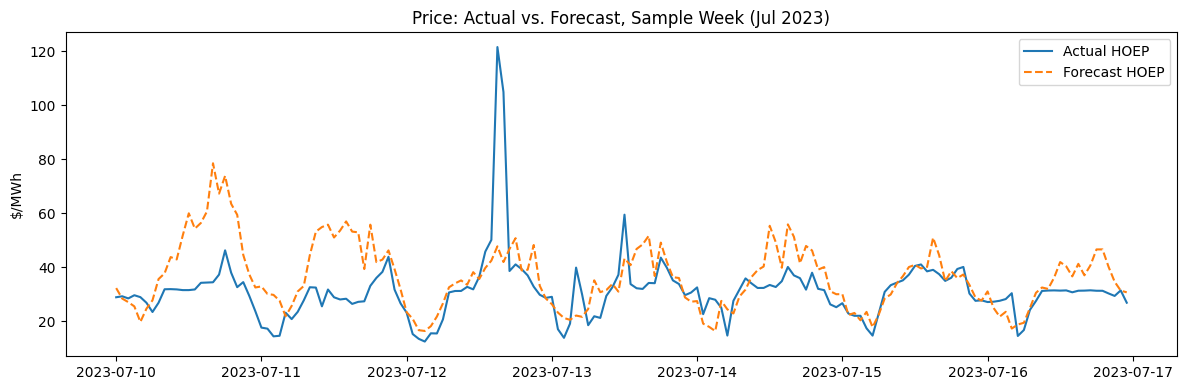

In [21]:
sample_week = test_2023[(test_2023['datetime'] >= '2023-07-10') & (test_2023['datetime'] < '2023-07-17')]
sample_preds = price_model.predict(sample_week[price_feature_cols])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample_week['datetime'], sample_week[PRICE_TARGET_COL], label='Actual HOEP')
ax.plot(sample_week['datetime'], sample_preds, label='Forecast HOEP', linestyle='--')
plt.title('Price: Actual vs. Forecast, Sample Week (Jul 2023)')
plt.ylabel('$/MWh')
plt.legend()
plt.tight_layout()
plt.show()

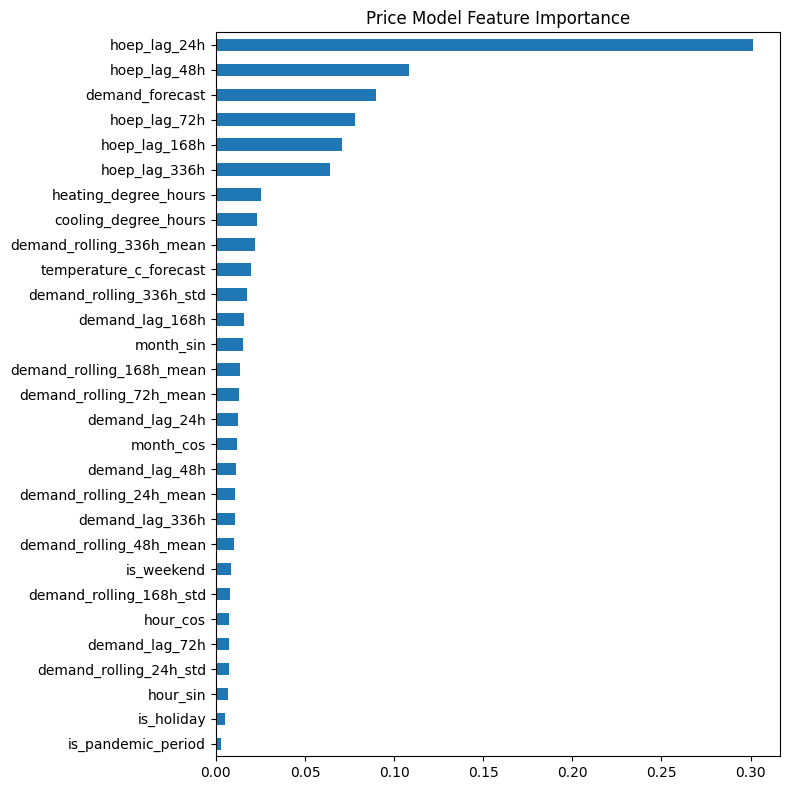

In [22]:
price_importances = pd.Series(price_model.feature_importances_, index=price_feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
price_importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
plt.title('Price Model Feature Importance')
plt.tight_layout()
plt.show()

### Save price forecasts

In [23]:
train_df['price_forecast'] = price_model.predict(train_df[price_feature_cols])
test_2023['price_forecast'] = price_model.predict(test_2023[price_feature_cols])
test_2024['price_forecast'] = price_model.predict(test_2024[price_feature_cols])
test_2025['price_forecast'] = price_model.predict(test_2025[price_feature_cols])

cols_to_save = ['datetime', PRICE_TARGET_COL, 'price_forecast', 'ontario_demand', 'demand_forecast']
train_df[cols_to_save].to_csv('../data/processed/price_forecast_train.csv', index=False)
test_2023[cols_to_save].to_csv('../data/processed/price_forecast_test_2023.csv', index=False)
test_2024[cols_to_save].to_csv('../data/processed/price_forecast_test_2024.csv', index=False)
test_2025[cols_to_save].to_csv('../data/processed/price_forecast_test_2025.csv', index=False)

print("Saved price forecasts for Phase 6.")

Saved price forecasts for Phase 6.
